# GRF model

This notebook attempts to reproduce the `nl_t_norm.R` script but using EconML. The goal is to have a nonlinear effect of `T` on the treatment effect `tau`, which can then be recovered. There's much more in here than would be needed, a lot of this is developing from a classic `X`-only model to a `X_T` model

In [88]:
from econml.grf import CausalForest, RegressionForest
from econml.dml import CausalForestDML
import numpy as np
import pandas as pd
import scipy.special
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import plot_tree

np.random.seed(42)

## Set up data

Step 1: create 'true' functions (these dont all work at present)

In [89]:
## y as true function of X
def true_y_x(X):
    #return (X[:,0] > 0) * X[:,0]
    return X[:,0]
## tau as true function X
def true_te_x(X):
    #return (X[:,0] > 0) * X[:,0]
    return X[:,0]

## y as true function of T
def true_y_t(T):
    return (T > 0) * T  
## tau as true function of T
def true_te_t(T, w_eff):
    return (T > 0) * w_eff 

Step 2: Set up experiment parameters

In [90]:
n_samples = 5000
n_features = 4
n_treatments = 1
n_outputs = 1

In [91]:
## Create features
X = np.random.normal(size=(n_samples, n_features))

In [92]:
## Create treatment
T = np.random.normal(size=(n_samples)) ## No confounder
# T = np.random.normal(size=(n_samples)) + 0.2 * X[:,0] ## Linear confounder
# T = np.random.normal(size=(n_samples)) + 0.2 * (X[:,0] > 0) ## Nonlinear confounder

In [93]:
## Make outcome: nonlinear treatment effect only
w_eff = 2
y = w_eff * true_y_t(T)

## Noise on Y
y_e = np.random.normal(loc = 0.0, scale = 0.1, size=(n_samples))
y = y + y_e 

Make up test data (for plotting), one with only `X` and one with `X` and `T`

In [94]:
## Test set for plotting
n_test = 100
X_test = np.zeros((n_test, n_features))
X_test[:,0] = np.linspace(-3, 3, 100)

X_T_test = np.zeros((n_test, n_features + 1))
X_T_test[:,n_features] = np.linspace(-3, 3, 100)

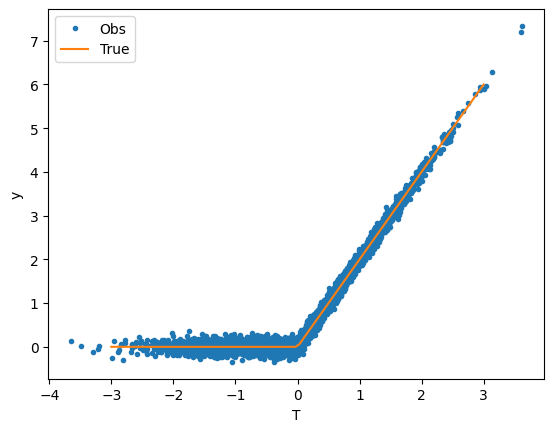

In [95]:
## Plot of y as function of T

plt.plot(T, y, '.', label = "Obs")
plt.plot(X_T_test[:,4], true_y_t(X_T_test[:,4]) * w_eff, label = "True")
plt.xlabel('T')
plt.ylabel('y')
plt.legend()

## 1. All-in-one model

Using `CasualForestDML` to fit model with `X`, `T` and `y`. Note that `T` is not included in `X` here

In [96]:
mod_cfdml = CausalForestDML(criterion='mse', n_estimators=400,
                            verbose=0, discrete_treatment=False,
                            n_jobs=-1, random_state=123)

In [97]:
%time mod_cfdml.fit(y, T, X=X)

CPU times: user 10.2 s, sys: 1.95 s, total: 12.2 s
Wall time: 6.53 s


Get ATE. Should be approx. 1 here as the true effect is either 0 or 2, with roughly 50% of samples in each group

In [98]:
tau = mod_cfdml.const_marginal_ate(X)
tau_lo, tau_hi = mod_cfdml.const_marginal_ate_interval(X)
print(f"ATE: {tau:.3f} ({tau_lo:.3f} - {tau_hi:.3f})")

ATE: 0.984 (0.828 - 1.139)


In [99]:
## Plot over range of X
tau_hat = mod_cfdml.effect(X_test)
lb, ub = mod_cfdml.effect_interval(X_test)

Plot over the range of X[:,0] (shouldn't show any pattern)

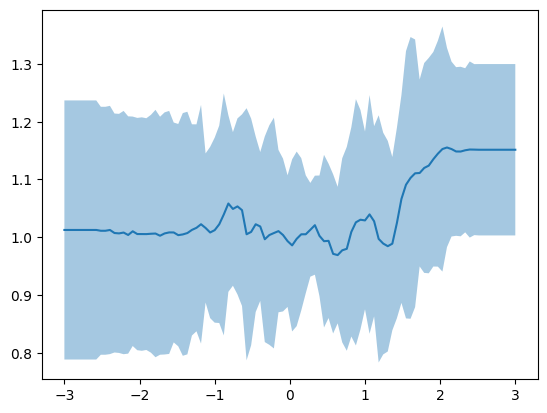

In [100]:
plt.plot(X_test[:,0], tau_hat)
plt.fill_between(X_test[:,0], lb, ub, alpha = 0.4)

## 2. Two stage estimator

Uses `RegressionForest` to create propensity and nuisance models and calculate residuals from these (`T'` and `y'`).

In [101]:
## Nusiance model
mod_n = RegressionForest()
mod_n.fit(X, y)

y_hat = mod_n.predict(X)
y_prime = y - y_hat[:,0]

In [102]:
## Propensity model
mod_p = RegressionForest()
mod_p.fit(X, T)

T_hat = mod_p.predict(X)
T_prime = T - T_hat[:,0]

Now use `CausalForest` to regress the two sets of residuals. Includes `X` as explanatory features for variations in CATE

In [103]:
mod_cf = CausalForest(criterion='het', n_estimators=400, 
                    verbose=0, 
                    n_jobs=-1, random_state=123)
# mod_cf.fit(X, T, y)
%time mod_cf.fit(X, T_prime, y_prime)

CPU times: user 2.35 s, sys: 82.4 ms, total: 2.43 s
Wall time: 391 ms


CausalForest(criterion='het', n_estimators=400, random_state=123)

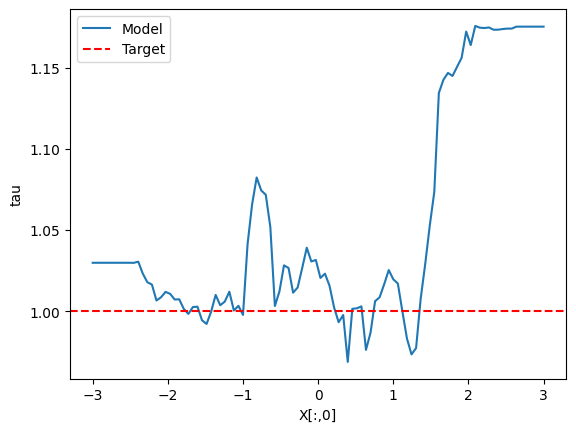

In [104]:
tau_hat = mod_cf.predict(X_test)
# lb, ub = mod_cf.effect_interval(X_test)

plt.plot(X_test[:,0], tau_hat, label='Model')
# plt.fill_between(X_test[:,0], lb, ub, alpha = 0.4)
plt.axhline(y=1, color='r', linestyle='--', label='Target')
plt.xlabel("X[:,0]")
plt.ylabel("tau")
plt.legend()

## 3. Two stage estimator

This now uses the estimates of `T'` and `y'` from the previous section, but includes `T` in the `X` array passed to `CausalForest`

In [105]:
X_T = np.concatenate((X, T[:, np.newaxis]), axis=1)

In [106]:
mod_cf = CausalForest(criterion='het', n_estimators=400, 
                    verbose=0, 
                    n_jobs=-1, random_state=123)
# mod_cf.fit(X, T, y)
%time mod_cf.fit(X_T, T_prime, y_prime)

CPU times: user 3.89 s, sys: 53.1 ms, total: 3.95 s
Wall time: 468 ms


CausalForest(criterion='het', n_estimators=400, random_state=123)

Plot true and estimated `tau` values across range of `T`

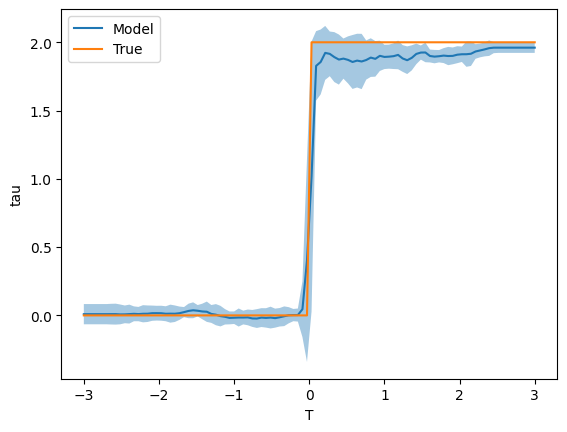

In [107]:
tau_hat = mod_cf.predict(X_T_test)
lb, ub = mod_cf.predict_interval(X_T_test)

plt.plot(X_T_test[:,4], tau_hat, label='Model')
plt.fill_between(X_T_test[:,4], lb[:,0], ub[:,0], alpha = 0.4)
plt.plot(X_T_test[:,4], true_te_t(X_T_test[:,4], w_eff), label='True')
plt.xlabel("T")
plt.ylabel("tau")
plt.legend()

And plot estimated outcome

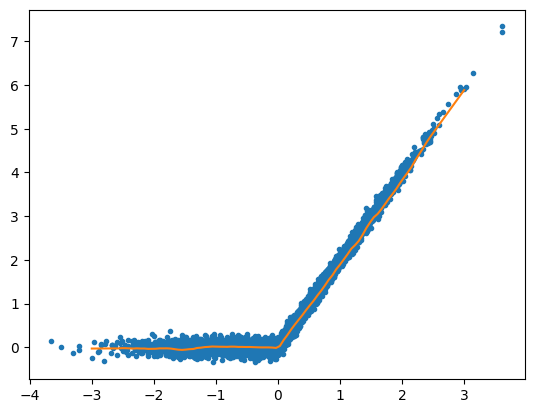

In [108]:
y_pred = tau_hat[:,0] * X_T_test[:,4]

plt.plot(T, y, '.', label = 'Obs')
#plt.plot(X_T_test[:,4], y_pred, label='Model')
# plt.fill_between(X_test[:,0], lb - y_pred, ub + y_pred, alpha = 0.4)
plt.plot(X_T_test[:,4], y_pred, label='True')